# BAN 8101 Predictive Analytics
## Week 5: Cross-Validation, Regularization & Feature Engineering

### Big Question
**How can we build models that generalize well to new data rather than simply fitting the training data well?**

### Learning Objectives
After this lecture, you should be able to:
- Explain why one train/test split may give an unstable estimate of performance
- Distinguish training, validation, and test data
- Explain and apply \(k\)-fold cross-validation
- Explain overfitting and underfitting
- Compare ordinary linear regression, Ridge, and Lasso
- Explain how regularization changes model coefficients
- Create and evaluate engineered features
- Select a model using validation performance and reserve the test set for final evaluation

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
print("Libraries loaded.")

Libraries loaded.


# 1. Load the Dataset

We will use scikit-learn's built-in **Diabetes regression dataset**.

The target is continuous, so this is a regression problem.

Our focus is not medical interpretation. We are using the dataset to study validation, regularization, and feature engineering.

In [13]:
data = load_diabetes(as_frame=True)
X = data.data.copy()
y = data.target.copy()

df = X.copy()
df["target"] = y

print("Shape:", df.shape)
display(df.head())
display(df.describe().T)

Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


# 2. Baseline Train/Test Split

A standard workflow is:

**Data → Training Set + Test Set → Fit Model → Evaluate**

But one split gives only one estimate of future performance.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

baseline = LinearRegression()
baseline.fit(X_train, y_train)
pred = baseline.predict(X_test)

print("MAE :", round(mean_absolute_error(y_test, pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)), 3))
print("R²  :", round(r2_score(y_test, pred), 3))

MAE : 42.794
RMSE: 53.853
R²  : 0.453


# 3. Why One Split Can Be Unstable

Different random splits can produce different test results.

That means our conclusion may partly depend on which observations happened to land in the test set.

In [15]:
rows = []

for seed in [1, 10, 20, 30, 42, 50, 100]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, random_state=seed
    )
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    p = model.predict(X_te)

    rows.append({
        "Random Seed": seed,
        "Test RMSE": np.sqrt(mean_squared_error(y_te, p))
    })

split_results = pd.DataFrame(rows)
split_results

,Random Seed,Test RMSE
0,1,54.704490
1,10,53.961207
2,20,58.835897
3,30,57.336545
4,42,53.853446
5,50,51.487471
6,100,51.330596


### Discussion
- Are all RMSE values identical?
- Which split looks best?
- Which split looks worst?
- Would it be risky to judge the model from only one split?

This motivates **cross-validation**.

# 4. Training, Validation, and Test Data

### Training Data
Used to fit model parameters.

### Validation Data
Used to compare models, features, and hyperparameters.

### Test Data
Used only for final evaluation after model selection.

A recommended workflow is:

**Full Data → Training Data + Test Data**

Then:

**Training Data → Cross-Validation → Model Selection**

Finally:

**Selected Model → Test Set → Final Evaluation**

# 5. How \(k\)-Fold Cross-Validation Works

With 5-fold cross-validation:

```text
Fold 1: [VALIDATE][TRAIN][TRAIN][TRAIN][TRAIN]
Fold 2: [TRAIN][VALIDATE][TRAIN][TRAIN][TRAIN]
Fold 3: [TRAIN][TRAIN][VALIDATE][TRAIN][TRAIN]
Fold 4: [TRAIN][TRAIN][TRAIN][VALIDATE][TRAIN]
Fold 5: [TRAIN][TRAIN][TRAIN][TRAIN][VALIDATE]
```

Each observation is used for validation once.

The average validation score gives a more stable estimate of out-of-sample performance.

In [16]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scores = cross_val_score(
    LinearRegression(),
    X_train,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -scores

print("Fold RMSE:", np.round(cv_rmse, 3))
print("Mean CV RMSE:", round(cv_rmse.mean(), 3))
print("Std CV RMSE :", round(cv_rmse.std(), 3))

Fold RMSE: [53.374 56.761 53.043 54.46  59.335]
Mean CV RMSE: 55.395
Std CV RMSE : 2.361


Answer: if two models have nearly the same CV RMSE, but one has much bigger variability across folds, which model will you make your prediction more confident?

pick the model with lower variability. 

# 6. Overfitting and Underfitting

### Underfitting
Model is too simple.

- poor training performance
- poor validation performance

### Good Generalization
Model captures useful structure.

- good training performance
- good validation performance

### Overfitting
Model learns the training data too closely.

- excellent training performance
- worse validation performance

The goal is **not** to maximize training performance.

The goal is to perform well on **new data**.

# 7. Why More Predictors Are Not Automatically Better

Adding predictors can improve training fit, but unnecessary predictors can also:

- increase model complexity
- increase variance
- make coefficients unstable
- reduce interpretability
- increase overfitting risk

One way to control complexity is **regularization**.

# 8. Regularization

Regularization adds a penalty for large coefficients.

The penalty strength is controlled by a parameter often written as:

$
\lambda
$

or in scikit-learn:

$
\alpha
$

Small $\alpha$ → weak regularization.

Large $\alpha$ → stronger regularization.

# 9. Ridge Regression

Ridge uses an $L_2$ penalty:

$$
\sum_{j=1}^{n}(\hat{y} - y)^2+\lambda\sum_{j=1}^{p}\beta_j^2
$$

1. First term: The standard RSS (measures how well the model fits the data).
2. Second term ($L2$ penalty): The sum of squared coefficients multiplied by a tuning parameter, $\alpha$ (often called $\lambda$ in some texts).
3. $\alpha$: Controls the strength of regularization.If $\alpha = 0$, Ridge regression turns back into standard OLS.As $\alpha$ increases, the penalty for large coefficients grows heavier, forcing them closer to zero.

Because the penalty depends on coefficient size, predictors should be standardized.

### Why it works

A. Coefficient Shrinking

Because the loss function penalizes large coefficients, the optimization algorithm is forced to balance minimizing the error and keeping the coefficient values small. Smaller coefficients mean the model's predictions change more smoothly and are less sensitive to small fluctuations or noise in individual features.

B. Handling Multicollinearity

When predictor variables are highly correlated (multicollinearity), standard OLS can result in unstable models with wildly fluctuating coefficient estimates. Mathematically, Ridge regression adds a positive constant ($\alpha$) to the diagonal of the feature matrix ($X^T X$) before taking its inverse:$$\hat{\beta}_{\text{ridge}} = (X^T X + \alpha I)^{-1} X^T y$$This adjustment ensures the matrix is always invertible and numerically stable, even when features are heavily correlated. It distributes the weight more evenly among correlated features rather than letting one take a massive positive coefficient and another a massive negative coefficient.

C. The Bias-Variance Tradeoff

Regularization relies on the bias-variance tradeoff:

Variance: Standard OLS has low bias but high variance (it changes drastically depending on the specific training sample).

Ridge: By artificially introducing a tiny bit of bias (forcing coefficients slightly smaller than their optimal OLS values), Ridge drastically reduces the variance of the model. The result is a model that makes slightly more generalized assumptions on the training set but performs significantly better on test data.

In [17]:
ridge_rows = []
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

for alpha in alphas:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error"
    )

    rmse = -scores

    ridge_rows.append({
        "Alpha": alpha,
        "Mean CV RMSE": rmse.mean(),
        "Std CV RMSE": rmse.std()
    })

ridge_results = pd.DataFrame(ridge_rows)
ridge_results

,Alpha,Mean CV RMSE,Std CV RMSE
0,0.001,55.394569,2.361527
1,0.010,55.393996,2.361810
2,0.100,55.388909,2.364335
3,1.000,55.374175,2.373206
4,10.000,55.435119,2.354739
5,100.000,56.001345,2.852619
6,1000.000,64.385853,5.067782


In [18]:
best_ridge = ridge_results.loc[ridge_results["Mean CV RMSE"].idxmin()]
best_ridge_alpha = float(best_ridge["Alpha"])

print("Best Ridge alpha:", best_ridge_alpha)
print("Best Ridge Mean CV RMSE:", round(best_ridge["Mean CV RMSE"], 3))

Best Ridge alpha: 1.0
Best Ridge Mean CV RMSE: 55.374


# 10. Lasso Regression

Lasso uses an $L_1$ penalty:

$$
\sum_{j=1}^{n}(\hat{y} - y)^2++\lambda\sum_{j=1}^{p}|\beta_j|
$$

### How Lasso Differs from Ridge (The Magic of $L1$)
##### A. Automatic Feature Selection (Sparse Models)
The most defining feature of Lasso is that it can drive coefficients all the way to zero.Because absolute values have a constant rate of penalty regardless of their size (unlike squared values, which shrink slower as they approach zero), Lasso aggressively forces unimportant feature coefficients to become exactly $0$.This means Lasso performs automatic feature selection, leaving you with a simpler, more interpretable model that only includes the most predictive variables.
##### B. Geometric Intuition
If you look at the constraint regions for the coefficients:Ridge has a circular/spherical constraint region ($x^2 + y^2 \le c$). The error contours usually touch the circle along a curve where no coefficients are zero.Lasso has a diamond-shaped constraint region with sharp corners on the axes ($\vert{}x\vert{} + \vert{}y\vert{} \le c$). The error contours of the model are much more likely to intersect the diamond right at one of these corners, where one of the coefficients is precisely zero.

In [19]:
lasso_rows = []
lasso_alphas = [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10]

for alpha in lasso_alphas:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=alpha, max_iter=100000))
    ])

    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error"
    )

    rmse = -scores

    lasso_rows.append({
        "Alpha": alpha,
        "Mean CV RMSE": rmse.mean(),
        "Std CV RMSE": rmse.std()
    })

lasso_results = pd.DataFrame(lasso_rows)
lasso_results

,Alpha,Mean CV RMSE,Std CV RMSE
0,0.001,55.393903,2.361802
1,0.010,55.387754,2.364434
2,0.100,55.353958,2.355868
3,0.500,55.352104,2.278126
4,1.000,55.388472,2.324856
5,2.000,55.532695,2.378128
6,5.000,56.322245,2.941740
7,10.000,57.702664,3.498099


In [20]:
best_lasso = lasso_results.loc[lasso_results["Mean CV RMSE"].idxmin()]
best_lasso_alpha = float(best_lasso["Alpha"])

print("Best Lasso alpha:", best_lasso_alpha)
print("Best Lasso Mean CV RMSE:", round(best_lasso["Mean CV RMSE"], 3))

Best Lasso alpha: 0.5
Best Lasso Mean CV RMSE: 55.352


# 11. Ridge vs. Lasso

| | Ridge | Lasso |
|---|---|---|
| Penalty | Squared coefficients | Absolute coefficients |
| Shrinks coefficients | Yes | Yes |
| Can set coefficients exactly to 0 | Usually no | Yes |
| Feature selection | Not directly | Yes |

Neither is automatically better. We compare them using validation performance.

In [21]:
best_lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=best_lasso_alpha, max_iter=100000))
])

best_lasso_model.fit(X_train, y_train)

coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_lasso_model.named_steps["lasso"].coef_
})

coef_table["Selected"] = np.abs(coef_table["Coefficient"]) > 1e-10
coef_table

,Feature,Coefficient,Selected
0,age,1.342257,True
1,sex,-10.390728,True
2,bmi,26.226224,True
3,bp,16.168921,True
4,s1,-11.664353,True
5,s2,0.000000,False
6,s3,-6.430902,True
7,s4,7.456048,True
8,s5,23.084930,True
9,s6,2.329573,True


| Feature | Ridge Regression ($L2$) | Lasso Regression ($L1$) |
| :--- | :--- | :--- |
| **Penalty Type** | Squared coefficients ($\beta^2$) | Absolute coefficients ($|\beta|$) |
| **Coefficient Shrinkage** | Shrinks coefficients close to, but rarely strictly equal to, zero. | Can shrink coefficients **strictly to zero** (feature selection). |
| **Multicollinearity** | Handles correlated features well by distributing weights among them. | Can be erratic with correlated features (tends to arbitrarily pick one and zero out the others). |
| **Best Used When** | You believe most or all features are useful and contribute to the target. | You have a high-dimensional dataset where many features are redundant or irrelevant. |

# 12. Feature Engineering

Feature engineering creates new predictors from existing variables.

Examples include:

- ratios
- interaction terms
- polynomial terms
- transformations

A new feature should not be kept just because it sounds useful.

We should test whether it improves **validation performance**.

In [22]:
X_eng = X.copy()
X_eng["bmi_squared"] = X_eng["bmi"] ** 2
X_eng["bmi_x_bp"] = X_eng["bmi"] * X_eng["bp"]

X_eng_train, X_eng_test, y_eng_train, y_eng_test = train_test_split(
    X_eng, y, test_size=0.20, random_state=RANDOM_STATE
)

eng_scores = cross_val_score(
    LinearRegression(),
    X_eng_train,
    y_eng_train,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

eng_rmse = -eng_scores

print("Engineered Feature Fold RMSE:", np.round(eng_rmse, 3))
print("Mean CV RMSE:", round(eng_rmse.mean(), 3))
print("Std CV RMSE :", round(eng_rmse.std(), 3))

Engineered Feature Fold RMSE: [54.968 55.783 53.391 53.485 58.907]
Mean CV RMSE: 55.307
Std CV RMSE : 2.015


### Discussion

- Did the engineered features reduce mean CV RMSE?
- Did they make performance more stable?
- If they did not help, should we keep them anyway?

A feature should earn its place through evidence.

# 13. Compare Candidate Models

We now compare:

1. Ordinary Linear Regression
2. Best Ridge model
3. Best Lasso model
4. Linear Regression with engineered features

In [23]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        f"Ridge (alpha={best_ridge_alpha:g})",
        f"Lasso (alpha={best_lasso_alpha:g})",
        "Engineered Features"
    ],
    "Mean CV RMSE": [
        cv_rmse.mean(),
        best_ridge["Mean CV RMSE"],
        best_lasso["Mean CV RMSE"],
        eng_rmse.mean()
    ],
    "Std CV RMSE": [
        cv_rmse.std(),
        best_ridge["Std CV RMSE"],
        best_lasso["Std CV RMSE"],
        eng_rmse.std()
    ]
}).sort_values("Mean CV RMSE")

comparison

,Model,Mean CV RMSE,Std CV RMSE
3,Engineered Features,55.306555,2.014550
2,Lasso (alpha=0.5),55.352104,2.278126
1,Ridge (alpha=1),55.374175,2.373206
0,Linear Regression,55.394633,2.361496


# 14. Select the Model Using Validation Performance

The preferred model should be selected using **cross-validation**, not repeated inspection of the test set.

The test set should remain untouched until model selection is complete.

In [24]:
best_model_name = comparison.iloc[0]["Model"]
print("Best model based on mean CV RMSE:")
print(best_model_name)

Best model based on mean CV RMSE:
Engineered Features


# 15. Final Test Evaluation

Now evaluate the selected candidate on the untouched test set.

In [25]:
if best_model_name == "Linear Regression":
    final_model = LinearRegression()
    final_X_train, final_X_test = X_train, X_test

elif best_model_name.startswith("Ridge"):
    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=best_ridge_alpha))
    ])
    final_X_train, final_X_test = X_train, X_test

elif best_model_name.startswith("Lasso"):
    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=best_lasso_alpha, max_iter=100000))
    ])
    final_X_train, final_X_test = X_train, X_test

else:
    final_model = LinearRegression()
    final_X_train, final_X_test = X_eng_train, X_eng_test

final_model.fit(final_X_train, y_train)
final_pred = final_model.predict(final_X_test)

print("Selected model:", best_model_name)
print("Test MAE :", round(mean_absolute_error(y_test, final_pred), 3))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, final_pred)), 3))
print("Test R²  :", round(r2_score(y_test, final_pred), 3))

Selected model: Engineered Features
Test MAE : 42.067
Test RMSE: 52.778
Test R²  : 0.474


# 16. Actual vs. Predicted

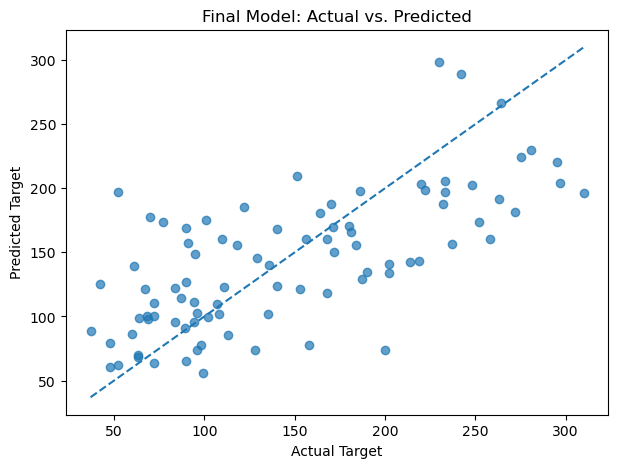

In [26]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, final_pred, alpha=0.7)

lo = min(y_test.min(), final_pred.min())
hi = max(y_test.max(), final_pred.max())
plt.plot([lo, hi], [lo, hi], linestyle="--")

plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Final Model: Actual vs. Predicted")
plt.show()

# 17. Residual Plot

\[
Residual=Actual-Predicted
\]

Residuals should ideally be distributed around zero without a strong systematic pattern.

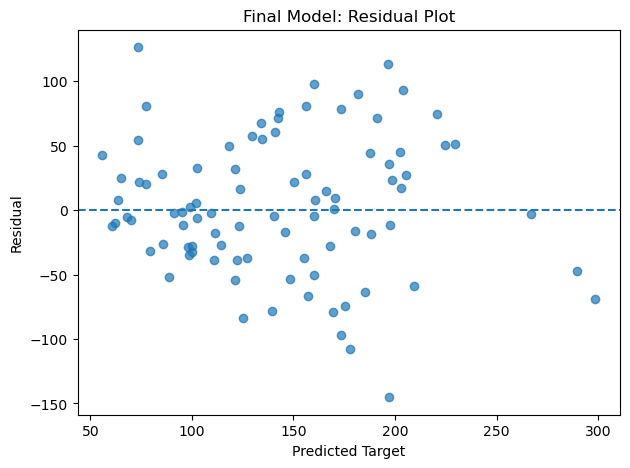

In [27]:
residuals = y_test - final_pred

plt.figure(figsize=(7,5))
plt.scatter(final_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Target")
plt.ylabel("Residual")
plt.title("Final Model: Residual Plot")
plt.show()

# 18. Connection to the Self-Driving Project

Overfitting will matter later when we train models using road images.

A model might perform very well on training images but fail under:

- different lighting
- different road positions
- different curves
- shadows
- unfamiliar visual conditions

Later, concepts such as validation data, regularization, augmentation, and robustness testing will help us build models that generalize.

The goal is not:

> "Can the car drive on the training examples?"

The goal is:

> **"Can the car drive successfully in situations it has not seen before?"**

# 19. Week 5 Takeaways

- A single train/test split can give an unstable estimate of performance.
- Cross-validation gives a more reliable estimate of generalization.
- Overfitting means a model performs well on training data but poorly on new data.
- Regularization controls model complexity.
- Ridge shrinks coefficients.
- Lasso can shrink coefficients to zero.
- Feature engineering should be tested, not assumed to help.
- Model selection should use validation performance.
- The final test set should be reserved for final evaluation.

### Key Principle

> **A model should be judged by how well it generalizes to new data, not by how well it remembers the training data.**

# Reflection Questions

1. Why can a single train/test split be misleading?
2. What does \(k\)-fold cross-validation do differently?
3. What is the difference between validation data and test data?
4. What is overfitting?
5. Why might adding more predictors hurt performance on new data?
6. What does regularization do to coefficients?
7. What is the key difference between Ridge and Lasso?
8. Why should engineered features be evaluated with cross-validation?
9. Why should the test set remain untouched during model selection?
10. How could overfitting affect the self-driving final project?

This will be discussion question for week 5. 